# I. Introduction

'''
MILESTONES 1

Nama : ROSALIA

Batch : REMOTE 053

This project analyzes customer purchase timing behavior using the theLook E-commerce dataset from Google BigQuery. Inspired by unique approah on winning customers through time-based promotional campaigns such as Shopee’s double-date events (1.1, 2.2, 3.3), the analysis explores how purchase timing may influence customer spending patterns through data preparation, visualization, and statistical analysis.

=================================================

'''

# II. Problem Statement & Dataset Description

## A. Topic
### Analyzing Customer Purchase Timing Behavior for theLook E-commerce

## B. Background

In the e-commerce industry, promotional campaigns are often used to attract more customers and increase sales. Many competitors such as Shopee and Lazada frequently run “double-date” promotions like 1.1, 2.2, 3.3, and 11.11, which often lead to a spike in online shopping activity. As an e-commerce company, theLook needs to understand whether the timing of purchases also affects customer spending behavior so the company can plan promotional campaigns more effectively.

## C. Problem Statement

To stay competitive in the e-commerce market, theLook needs to better understand when customers tend to make purchases. This project analyzes customer purchase timing using the theLook e-commerce dataset to identify patterns across different hours of the day and between weekdays and weekends. The goal is to see whether certain time periods are associated with higher purchase activity or spending.

## D. SMART Analysis

**1. Specific**
Analyzing customer purchase timing behavior in an e-commerce dataset to understand when customers tend to make purchases and whether certain time periods are linked to higher spending.

**2. Measurable** 
The analysis will measure customer purchase timing behavior using descriptive statistics such as mean, median, and standard deviation of purchase prices. Data visualization techniques, including bar charts, line charts, and histograms, will be created using Python to help identify patterns in purchasing activity.

**3. Achievable**
The study will use around 5,000 transaction records from the theLook E-commerce. The dataset available is from Google BigQuery, which includes information such as purchase time and transaction value.

**4. Relevant**
The relevancy to understand when customers are more likely to shop can help e-commerce companies plan promotional campaigns or sales events at the most optimum time.

**5. Time-bound**
This analysis will be completed during the project period by preparing the dataset, creating visualizations, and performing statistical analysis. The study will examine purchase activity across different hours of the day and compare purchasing behavior between weekdays and weekends, as well as compare the average purchase price across these time periods to identify timing-related patterns.

## E. Dataset

The dataset used in this project is the theLook E-commerce dataset available on Google BigQuery Public Dataset. 

**Source:**
Google BigQuery Public Dataset – theLook E-commerce

https://console.cloud.google.com/marketplace/product/bigquery-public-data/thelook-ecommerce

### Original Tables in Dataset
- distribution_centers
- events
- inventory_items
- order_items
- orders
- products
- users

For this analysis, only the tables relevant to purchase behavior were selected. 

The **order_items** table was used because it contains transaction information such as: 
- purchase price
- purchase time. 

The **products** table was used to obtain:
- product category

The **users** table was used to obtain customer demographic information such as:
- gender. 

After knowing which tables to choose, these tables were joined using their ID columns so that information we need (purchase price, purchase time, product category, and customer gender) could be combined into one dataset for analysis.

The main variables used in this project are: 
- **sale_price** (purchase price) : to measure customer spending
- **created_at** (time of purchase) : to extract hour of day and weekday vs weekend
- **category** (product category) : to see if spending patterns will be different by product type
- **gender** (customer gender) : to explore simple demographic differences

A sample of around **5,000 rows** will be used for the analysis to keep the dataset manageable while still meeting the project requirements.

## F. Problem Breakdown & Methods Used

1. At what hours of the day do customers make the most purchases?
- Method: **Count chart** – purchase count by hour.

2. Is there a difference in purchasing activity between weekdays and weekends?
- Method: **Pie chart** – comparing weekday vs weekend purchase proportions.

3. How are purchase prices distributed among transactions?
- Method: **Histogram** – showing the distribution of purchase prices.

4. How does the average purchase price differ between male and female customers?
- Method: **Bar chart** – comparing average purchase price by gender.

5. What are the mean, median, and standard deviation of purchase prices?
- Method: **Descriptive statistics** - mean, median, standard deviation

6. Is there a statistically significant difference in average purchase price between weekday and weekend purchases?
- Method: **Inferential statistics (Independent T-test)** 


### Library : 

The data visualizations in this analysis are created using **Python libraries Matplotlib and Seaborn**.

# III. Data Loading

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# SQL from BigQuery

# SELECT
#   order_items.sale_price,
#   order_items.created_at,
#   products.category,
#   users.gender
# FROM `bigquery-public-data.thelook_ecommerce.order_items` AS order_items
# JOIN `bigquery-public-data.thelook_ecommerce.products` AS products
# ON order_items.product_id = products.id
# JOIN `bigquery-public-data.thelook_ecommerce.users` AS users
# ON order_items.user_id = users.id
# LIMIT 5000

In [2]:
# Load dataset

df = pd.read_csv("P0M1_ROSALIA_dataset.csv")
df.head()

,sale_price,created_at,category,gender
0,0.02,2023-07-22 23:39:21.000000 UTC,Accessories,F
1,0.02,2024-09-16 11:55:28.000000 UTC,Accessories,F
2,0.02,2025-10-12 11:33:27.000000 UTC,Accessories,F
3,0.02,2025-05-24 17:38:11.000000 UTC,Accessories,F
4,0.02,2023-11-24 18:42:07.000000 UTC,Accessories,F


**Insights** : From above, the dataset contains four columns: sale_price, created_at, category, and gender.
This confirms that the dataset has the necessary variables needed for the analysis.

In [4]:
# Check Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sale_price  5000 non-null   float64
 1   created_at  5000 non-null   object 
 2   category    5000 non-null   object 
 3   gender      5000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 156.4+ KB


**Insights** 

Based on the dataset structure, the dataset contains **5,000 rows and 4 columns**. 
All variables have **5,000 non-null values**, indicating that there are no missing values in the dataset. 

The "sale_price" variable is stored as a numeric data type (float), while "created_at", "category", and "gender" are stored as object data types. 

The "created_at" column will later need to be converted into datetime format for time-based analysis.

In [5]:
# Statistics Summary

df.describe()

,sale_price
count,5000.000000
mean,6.787410
std,1.784026
min,0.020000
25%,5.950000
50%,7.000000
75%,8.000000
max,8.990000


**Insights**

Based on the summary statistics, the dataset contains **5,000 purchase transactions**. 

The average purchase price (sale_price) is around **6.79**, with a median value of **7.00**, indicating that most purchase prices are around this range. 

The minimum price is **0.02** and the maximum price is **8.99**, showing some variation in product prices

In [6]:
# Check Missing Values

df.isnull().sum()

sale_price    0
created_at    0
category      0
gender        0
dtype: int64

**Insights**

The missing value check shows that all variables (sale_price, created_at, category, and gender) have **0 missing values**. 

This indicates that the dataset is complete and no missing value treatment is required before data cleaning and analysis stages.

# IV. Data Cleaning

In [7]:
# Convert created_at to datetime

df['created_at'] = pd.to_datetime(df['created_at'])

In [8]:
# Check 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   sale_price  5000 non-null   float64            
 1   created_at  5000 non-null   datetime64[ns, UTC]
 2   category    5000 non-null   object             
 3   gender      5000 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 156.4+ KB


**Insights**

After converting the "created_at" column to "datetime" format, the dataset structure shows that all variables now have appropriate data types for analysis. 

This allows time-based features such as purchase hour and day type (weekdays/weekend) to be extracted for further analysis.

In [ ]:
# Create Purchase Hour

df['hour'] = df['created_at'].dt.hour

In [10]:
# Check

df.head()

,sale_price,created_at,category,gender,hour
0,0.02,2023-07-22 23:39:21+00:00,Accessories,F,23
1,0.02,2024-09-16 11:55:28+00:00,Accessories,F,11
2,0.02,2025-10-12 11:33:27+00:00,Accessories,F,11
3,0.02,2025-05-24 17:38:11+00:00,Accessories,F,17
4,0.02,2023-11-24 18:42:07+00:00,Accessories,F,18


**Insights**

A new variable called **hour** was successfully created from the "created_at" column. 

This variable represents the hour when each purchase was made. It will be used to analyze customer purchasing activity at different times of the day.

In [ ]:
# Create Day_Type : Weekdays & Weekend

df['day_type'] = df['created_at'].dt.dayofweek
df['day_type'] = df['day_type'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

In [12]:
# Check

df.head()

,sale_price,created_at,category,gender,hour,day_type
0,0.02,2023-07-22 23:39:21+00:00,Accessories,F,23,Weekend
1,0.02,2024-09-16 11:55:28+00:00,Accessories,F,11,Weekday
2,0.02,2025-10-12 11:33:27+00:00,Accessories,F,11,Weekend
3,0.02,2025-05-24 17:38:11+00:00,Accessories,F,17,Weekend
4,0.02,2023-11-24 18:42:07+00:00,Accessories,F,18,Weekday


**Insights**

Day type : Weekend & Weekdays have been created. 

In [13]:
# Check Distribution 

df['day_type'].value_counts()

day_type
Weekday    3603
Weekend    1397
Name: count, dtype: int64

**Insights**

The distribution shows that most transactions occur on **weekdays (3,603 transactions)** 
compared to **weekends (1,397 transactions)**. 

This indicates that customers tend to make purchases more frequently during weekdays than weekends in this dataset.


# V. Exploration and Analysis

## Visualization 1
Purchases by Hour of the Day

### Questions:
At what hours of the day do customers make the most purchases?

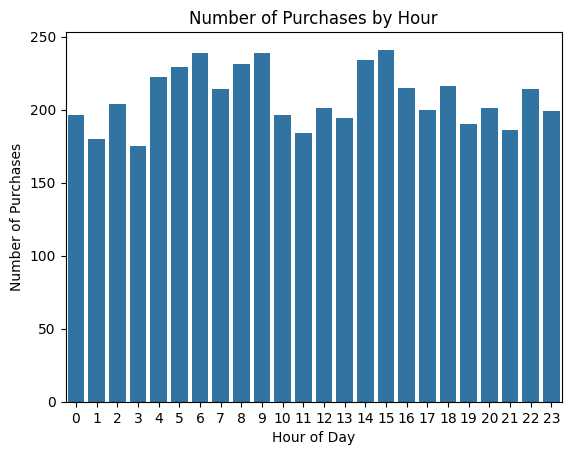

In [14]:
# Purchase by Hour

sns.countplot(x='hour', data=df)

plt.title("Number of Purchases by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Purchases")

plt.show()

**Insights**

The chart shows the number of purchases made at different hours of the day (from 00.00 midnite until 23.00PM)

Overall, purchase activity is mostly distributed throughout the day, but slightly higher activity can be observed: 
- in the morning (6AM, 8-9AM)
- and afternoon (2-3PM). 

This suggests that customers tend to make purchases more frequently during these periods compared to late night or very early morning hours.


## Visualization 2
Weekday vs Weekend Purchases

### Questions:
Is there a difference in purchasing activity between weekdays and weekends?

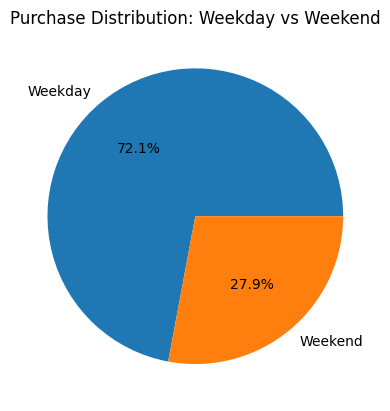

In [15]:
# Count Weekday vs Weekend
day_counts = df['day_type'].value_counts()

# Pie chart
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%')
plt.title("Purchase Distribution: Weekday vs Weekend")
plt.show()

**Insights**

The pie chart shows the distribution of purchases between weekdays and weekends. 
Most purchases occur on:
- weekdays (72%)
- weekends (28%)

This showed that customers tend to shop more frequently during weekdays compared to weekends.

## Visualization 3
Purchase Price Distribution

### Questions:
How are purchase prices distributed among transactions?

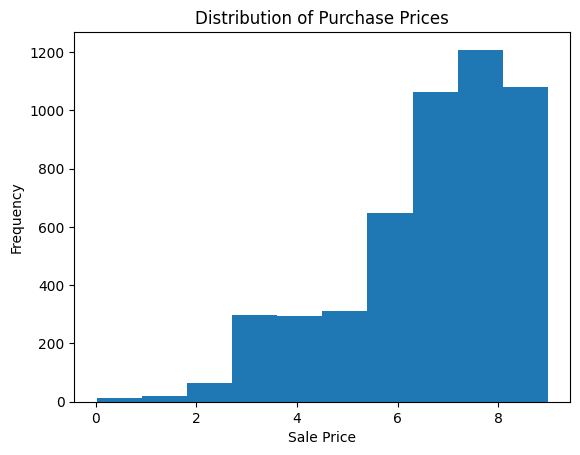

In [16]:
# Purchase prices (using histogram)
plt.hist(df['sale_price'])

plt.title("Distribution of Purchase Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

**Insights**

The histogram shows the distribution of purchase prices in the dataset.
 
Most transactions are concentrated in the price range of around 6-8. 
This showed that many products are sold within this price range. 

Only a small number of transactions occur at much lower price values.


## Visualization 4
Average Purchase Price by Gender

### Questions:
How does the average purchase price differ between male and female customers?

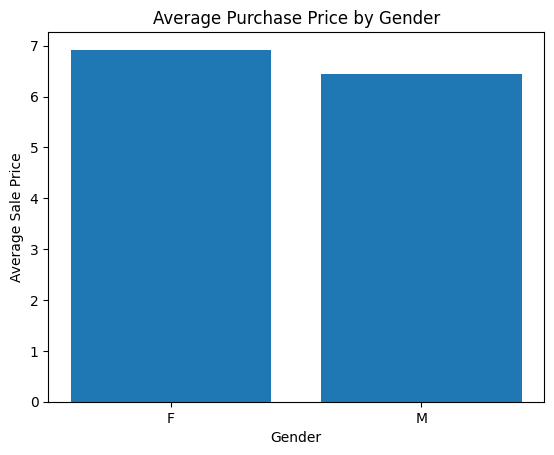

In [18]:
# Calculate average purchase price by gender
avg_price_gender = df.groupby('gender')['sale_price'].mean()

# Bar chart
plt.bar(avg_price_gender.index, avg_price_gender)

plt.title("Average Purchase Price by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Sale Price")

plt.show()

**Insights**

The bar chart shows the average purchase price for male and female customers. 

Female customers have a slightly higher average purchase price compared to male customers. 

However, the difference between the two groups is relatively small, this showed that both male and female customers spend similar amounts per purchase.


## Question 5
Statistics Descriptive

### Questions:
What are the mean, median, and standard deviation of purchase prices?

In [19]:
# Calculate mean, median, std
mean_price = df['sale_price'].mean()
median_price = df['sale_price'].median()
std_price = df['sale_price'].std()

print("Mean:", mean_price)
print("Median:", median_price)
print("Standard Deviation:", std_price)

Mean: 6.787409917742014
Median: 7.0
Standard Deviation: 1.7840259243076377


**Insights**

- Mean = 6.79	average spending per transaction
- Median = 7.00	middle purchase value
- Std = 1.78	, means prices don't vary too widely.

The close values between the mean and median showed that the purchase prices are mostly distributed without strong skewness. 

The standard deviation of 1.78 indicates that most purchase prices do not vary far from the average value.

## Question 6
Statistics Inferential 

### Questions:
Is there a statistically significant difference in average purchase price between weekday and weekend purchases?

In [20]:
# Breakdown Weekday & Weekend Prices

weekday_prices = df[df['day_type'] == 'Weekday']['sale_price']
weekend_prices = df[df['day_type'] == 'Weekend']['sale_price']

In [21]:
# Use T-test

from scipy import stats

t_stat, p_value = stats.ttest_ind(weekday_prices, weekend_prices)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.6502015123043745
P-value: 0.09896456205327872


**Insights**

T-statistic = 1.65

P-value = 0.0989

Rule used in statistics:
- p-value < 0.05 → significant difference
- p-value > 0.05 → no significant difference

Since:
0.0989 > 0.05
--> there is NO statistically significant difference.

An independent t-test was conducted to examine whether there is a difference in average purchase price between weekday and weekend transactions. The result shows a p-value of 0.099, which is higher than the significance level of 0.05. 

This showed that there is NO statistically significant difference in average purchase price between weekdays and weekends.

Customers tend to spend a similar amount regardless of the day they make a purchase.

# VI. Conclusion

This analysis explored customer purchasing behavior on the theLook e-commerce platform by looking at purchase timing and spending patterns. 

Key findings:

### **Purchase by hour** 
– Customers make purchases throughout the day (mostly early morning & afternoon), although some hours show slightly higher activity.

### **Weekday vs weekend purchases** 
– Most transactions happen on weekdays compared to weekends.

### **Purchase price distribution** 
– Most purchase prices fall within a similar range, showing that customer spending is fairly consistent.

### **Spending by gender** 
– The average purchase price between male and female customers is quite similar, with only a small difference.

### **Statistics Descriptive** 
– The mean and median purchase prices are close to each other, which suggests that the purchase prices are evenly distributed.

### **Statistics Differential (t-test)** 
– The t-test result shows that there is not much difference in average purchase price between weekday and weekend purchases.

***To conclude***, the analysis showed that purchase timing may influence when customers shop, but it does not strongly affect how much they spend in each transaction. 

# Next Part : Tableau 

In [22]:
# Export Clean Dataset from Pythong

df.to_csv("P0M1_ROSALIA_dataset_CLEAN.csv", index=False)